## imports

In [8]:
# 
import numpy as np
import pandas as pd
import hypertools as hyp
import numpy as np
import os
import re
import pickle
import brainiak.eventseg.event as event
from num2words import num2words
from scipy.spatial.distance import cdist
from scipy.signal import resample
from scipy.stats import zscore
from scipy.spatial.distance import correlation
from scipy.interpolate import interp1d as interpolate
from itertools import zip_longest
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib as mpl
import mpl_toolkits.mplot3d
import seaborn as sns
%matplotlib inline

## set paths

In [9]:
#
ep_model_dir = '../../data/models/episodes/'
ep_traj_dir = os.path.join(ep_model_dir, 't100_w50/', 'trajectories')
ep_seg_dir = os.path.join(ep_model_dir, 't100_w50/', 'events')
ep_emb_dir = os.path.join(ep_model_dir, 't100_w50/', 'embeddings')
rec_model_dir = '../../data/models/participants/'
rec_traj_dir = os.path.join(rec_model_dir, 'trajectories')
rec_seg_dir = os.path.join(rec_model_dir, 'events', 'k:1000')
rec_emb_dir = os.path.join(rec_model_dir, 'embeddings')
pickle_dir = '../../data/pickles/'

## load data

In [10]:
# episode trajectories
episode_trajectories = {episode : np.load(os.path.join(ep_traj_dir,episode+'_model_t100_w50_res.npy')) for episode
                       in ['atlep1','atlep2','arrdev']}

# episode events
episode_events = {episode : np.load(os.path.join(ep_seg_dir,episode+'_events.npy')) 
                  for episode in ['atlep1','atlep2','arrdev']}

# episode eventseg models
episode_eventseg_models = {episode : pickle.load(open(os.path.join(pickle_dir, 'eventseg-models', 
                                                                   episode+'_eventseg_model.p'), 'rb')) 
                           for episode in ['atlep1', 'atlep2', 'arrdev']}

# individual participant trajectories
participant_trajectories = {'atlep1' : [], 'atlep2' : [], 'arrdev' : [], 'delayed': [], 'prediction' : []}

for root, dirs, files in os.walk(rec_traj_dir, topdown=True):
    dirs[:] = [d for d in dirs if d not in ['vidwProp', 'vidwProp_recwProp']]
    traj_models = [f for f in files if f.startswith('debug') and f.endswith('.npy')]
    for f_name in traj_models:
        t = np.load(os.path.join(root,f_name))
        participant_trajectories[os.path.split(root)[-1]].append((f_name.split('.')[0],t))
        
# average participant trajectories
avg_participant_trajectories = {rectype : np.load(os.path.join(rec_traj_dir, rectype, 'avg_trajectory.npy')) for 
                               rectype in ['atlep1','atlep2','arrdev','delayed','prediction']}


# individual participant events
participant_events = {'atlep1' : [], 'atlep2' : [], 'arrdev' : [], 'delayed': [], 'prediction' : []}

for root, dirs, files in os.walk(rec_seg_dir):
    events_models = [f for f in files if f.startswith('debug') and f.endswith('events.npy')]
    for f_name in events_models:
        m = np.load(os.path.join(root,f_name))
        participant_events[os.path.split(root)[-1]].append((f_name.split('_')[0],m))

# average participant events
avg_participant_events = {rectype : np.load(os.path.join(rec_seg_dir,rectype,'avg_events.npy')) 
                         for rectype in ['atlep1','atlep2','arrdev','delayed','prediction']}
        
# episode-recall event mappings
event_mappings = dict()
for rectype in ['atlep1','atlep2','arrdev','delayed','prediction']:
    with open(os.path.join(rec_seg_dir,rectype,'event_mappings.p'), 'rb') as f:
        event_mappings[rectype] = pickle.load(f)
        
# session 1/session 2 psiturk ID mapppings
with open(os.path.join(pickle_dir,'id_maps.p'), 'rb') as f:
    id_maps = pickle.load(f)
    
# event-segmented models
with open(pickle_dir+'participant_max_ks.p', 'rb') as f:
    participant_max_ks = pickle.load(f)

participant_eventsegs = {k : [] for k in participant_max_ks.keys()}
for rectype, maxklist in participant_max_ks.items():
    for (turkid, maxk) in maxklist:
        eseg = np.load(os.path.join(rec_model_dir, 'eventseg-models', rectype, turkid, maxk))
        participant_eventsegs[rectype].append((turkid, eseg))

## pre-define some functions

In [11]:
def draw_bounds(ax, model):
    if isinstance(model, event.EventSegment):
        model = model.segments_[0]
        
    bounds = np.where(np.diff(np.argmax(model, axis=1)))[0]
    bounds_aug = np.concatenate(([0],bounds,[model.shape[0]]))
    for i in range(len(bounds_aug)-1):
        rect = patches.Rectangle((bounds_aug[i], bounds_aug[i]), bounds_aug[i+1]-bounds_aug[i], 
                                 bounds_aug[i+1]-bounds_aug[i], linewidth=1, edgecolor='#FFF9AE', 
                                 facecolor='none')
        ax.add_patch(rect)
    return ax

def _z2r(z):
    """
    Function that calculates the inverse Fisher z-transformation

    Parameters
    ----------
    z : int or ndarray
        Fishers z transformed correlation value

    Returns
    ----------
    result : int or ndarray
        Correlation value

    """
    with np.errstate(invalid='ignore', divide='ignore'):
        return (np.exp(2 * z) - 1) / (np.exp(2 * z) + 1)
    
def _r2z(r):
    """
    Function that calculates the Fisher z-transformation

    Parameters
    ----------
    r : int or ndarray
        Correlation value

    Returns
    ----------
    result : int or ndarray
        Fishers z transformed correlation value

    """
    with np.errstate(invalid='ignore', divide='ignore'):
        return 0.5 * (np.log(1 + r) - np.log(1 - r))
    
def corr_mean(rs, axis=0):
    """
    Function that calculates the mean of correlation coefficients,
    performing Fisher z-transformation and inverse z-transormation
    
    Parameters
    ----------
    rs: : list or ndarray
        Correlation values
    
    Returns
    ----------
    result : float
        mean of correlation values

    """
    return _z2r(np.nanmean([_r2z(r) for r in rs], axis=axis))

# code for later plots

In [12]:
cmap = plt.cm.bone_r

### episode topic models

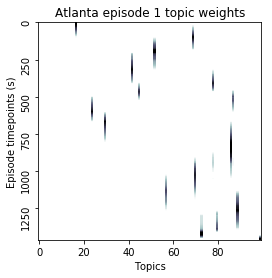

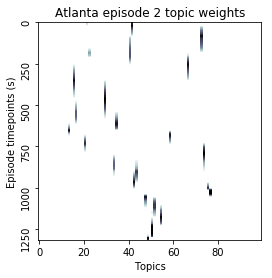

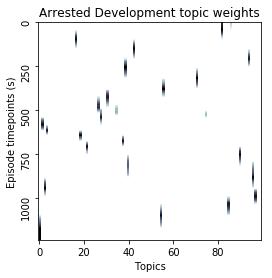

In [151]:
for ep, traj in episode_trajectories.items():
    
    if ep == 'atlep1':
        title = 'Atlanta episode 1'
    elif ep == 'atlep2':
        title = 'Atlanta episode 2'
    else:
        title = 'Arrested Development'
    fig, a = plt.subplots(1,1)
    fig.set_size_inches(4,4)
    data = pd.DataFrame(traj)
    sns.heatmap(data, cmap=cmap, xticklabels=20, yticklabels=250, vmin=0, vmax=1, cbar=False, ax=a)
    a.set_title('{} topic weights'.format(title))
    a.set_ylabel('Episode timepoints (s)')
    a.set_xlabel('Topics')
    
    for _, spine in a.spines.items():
        spine.set_visible(True)
        
    a.collections[0].remove()
    a.imshow(data, aspect='auto', cmap=cmap)
#     plt.savefig('../../figures/{}_topic_weights.pdf'.format(ep))
    plt.show()

### episode corrmats

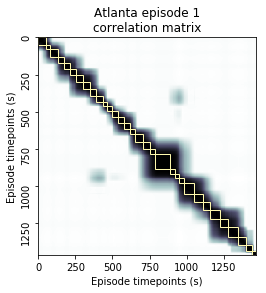

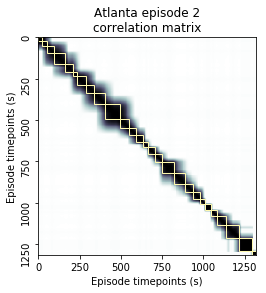

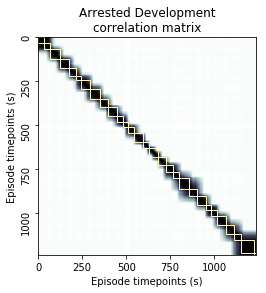

In [125]:
for ep, traj in episode_trajectories.items():
    if ep == 'atlep1':
        name = 'Atlanta episode 1'
    elif ep == 'atlep2':
        name = 'Atlanta episode 2'
    else:
        name = 'Arrested Development'
    data = pd.DataFrame(traj).T.corr()
    a = sns.heatmap(data, cmap=cmap, xticklabels=250, yticklabels=250, vmin=0, vmax=1, cbar=False)
    a.set_title(name + '\ncorrelation matrix')
    a.set_ylabel('Episode timepoints (s)')
    a.set_xlabel('Episode timepoints (s)')
    for _, spine in a.spines.items():
        spine.set_visible(True)
    a = draw_bounds(a, episode_eventseg_models[ep])
    a.collections[0].remove()
    a.imshow(data, aspect='auto', cmap=cmap)
    a.set_aspect('equal')
#     plt.savefig('../../figures/{}_corrmat.pdf'.format(ep))
    plt.show()

### episode events

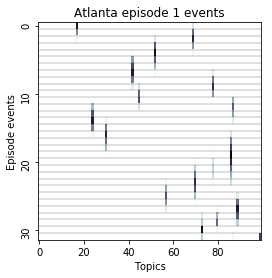

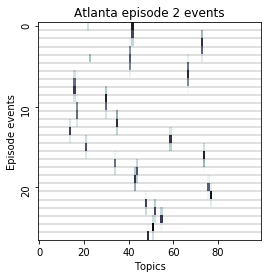

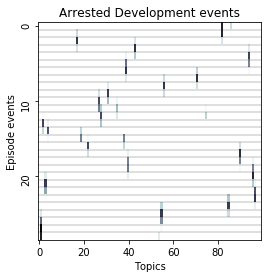

In [152]:
for ep, events in episode_events.items():
    if ep == 'atlep1':
        title = 'Atlanta episode 1'
    elif ep == 'atlep2':
        title = 'Atlanta episode 2'
    else:
        title = 'Arrested Development'
    
    fig, a = plt.subplots(1,1)
    fig.set_size_inches(4,4)    
    
    data = pd.DataFrame(events)
    a = sns.heatmap(data, cmap=cmap, xticklabels=20, yticklabels=10, vmin=0, vmax=1, cbar=False, ax=a)
    a.set_title('{} events'.format(title))
    a.set_ylabel('Episode events'.format(title))
    a.set_xlabel('Topics')
    
    for _, spine in a.spines.items():
        spine.set_visible(True)
        
    a.hlines(list(range(events.shape[0])), *a.get_xlim(), linewidth=0.25)
    plt.savefig('../../figures/{}_events.pdf'.format(ep))
    plt.show()

In [146]:
a.get_xlim()

(0.0, 100.0)

### avg participant corrmats

In [130]:
# for rectype, traj in avg_participant_trajectories.items():
#     data = pd.DataFrame(traj).T.corr()
#     a = sns.heatmap(data, cmap=cmap, xticklabels=250, yticklabels=250, vmin=0, vmax=1)
#     a.set_title('average ' + rectype + ' correlation matrix')
#     a.collections[0].remove()
#     a.imshow(data, aspect='auto', cmap=cmap)
#     plt.show()

### avg participant matchmats

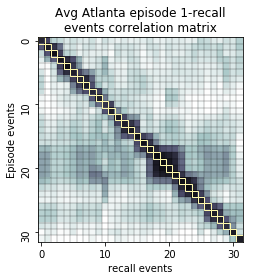

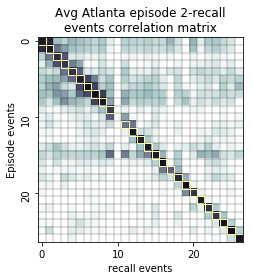

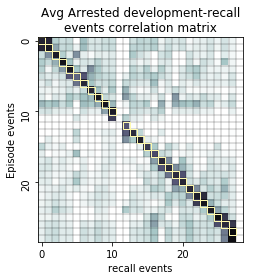

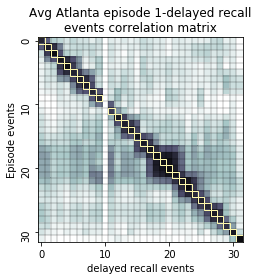

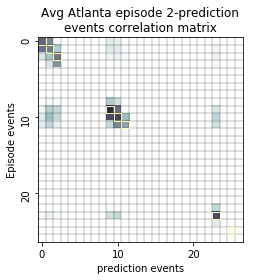

In [142]:
for rectype, avgp_events, in avg_participant_events.items():
    if rectype == 'delayed':
        ep_events = episode_events['atlep1']
        rt = 'delayed recall'
        et = 'Atlanta episode 1'
    elif rectype == 'prediction':
        ep_events = episode_events['atlep2']
        et = 'Atlanta episode 2'
        rt = 'prediction'
    else:
        ep_events = episode_events[rectype]
        rt = 'recall'
        if rectype == 'atlep1':
            et = 'Atlanta episode 1'
        elif rectype == 'atlep2':
            et = 'Atlanta episode 2'
        else:
            et = 'Arrested development'
        
    data = 1 - cdist(ep_events, avgp_events, 'correlation')
    
    a = sns.heatmap(data, cmap=cmap, xticklabels=10, yticklabels=10, vmin=0, vmax=1, cbar=False)
    a.set_title('Avg {}-{}\nevents correlation matrix'.format(et, rt))
    a.set_ylabel('Episode events')
    a.set_xlabel('{} events'.format(rt))
    
    for _, spine in a.spines.items():
        spine.set_visible(True)
    
    a.hlines(list(range(data.shape[0])), *a.get_xlim(), linewidth=.25)
    a.vlines(list(range(data.shape[1])), *a.get_ylim(), linewidth=.25)
    
    bounds = np.argmax(data, axis=0)
    for i in range(len(bounds)):
        if i > 0 and bounds[i] == 0:
            continue
        rect = patches.Rectangle((i,bounds[i]), 1, 1, linewidth=1, edgecolor='#FFF9AE',facecolor='none', zorder=2)
        a.add_patch(rect)
        
    a.set_aspect('equal')
    plt.tight_layout()
    plt.savefig('../../figures/{}_avgp_matchmat.pdf'.format(rectype))
    plt.show()

### participant corrmats

In [53]:
# for rectype, p_trajs in participant_trajectories.items():
#     fig, axes = plt.subplots(len(p_trajs)//6 + 1, 6)
#     fig.set_size_inches(len(axes[0])*2,len(axes)*2)
#     axes = axes.flatten()

#     for ax, (turkid, traj) in zip_longest(axes, p_trajs, fillvalue=(None, None)):

#         if turkid is None:
#             ax.axis('off')
#             continue

#         data = pd.DataFrame(traj).T.corr()
#         ax = sns.heatmap(data, cmap=cmap, xticklabels=250, yticklabels=250, vmin=0, vmax=1, cbar=False, ax=ax)
#         #a.set_title(turkid)

#         for _, spine in a.spines.items():
#             spine.set_visible(True)

#         p_eventseg = next(esm for tid, esm in participant_eventsegs[rectype] if tid==turkid)
#         ax = draw_bounds(ax, p_eventseg)
#         ax.collections[0].remove()
#         ax.imshow(data, aspect='auto', cmap=cmap)
#     plt.tight_layout()
#     #fig.savefig('../../figures/corrmats-'+rectype+'_k:50.pdf')


### participant matchmats

In [6]:
corrmats = {k : None for k in participant_events.keys()}

for rectype, r_events in participant_events.items():
    if rectype == 'delayed':
        ep_events = episode_events['atlep1']
    elif rectype == 'prediction':
        ep_events = episode_events['atlep2']
    else:
        ep_events = episode_events[rectype]
    corrmats[rectype] = [(turkid, 1 - cdist(ep_events, r, 'correlation')) for (turkid, r) in r_events]

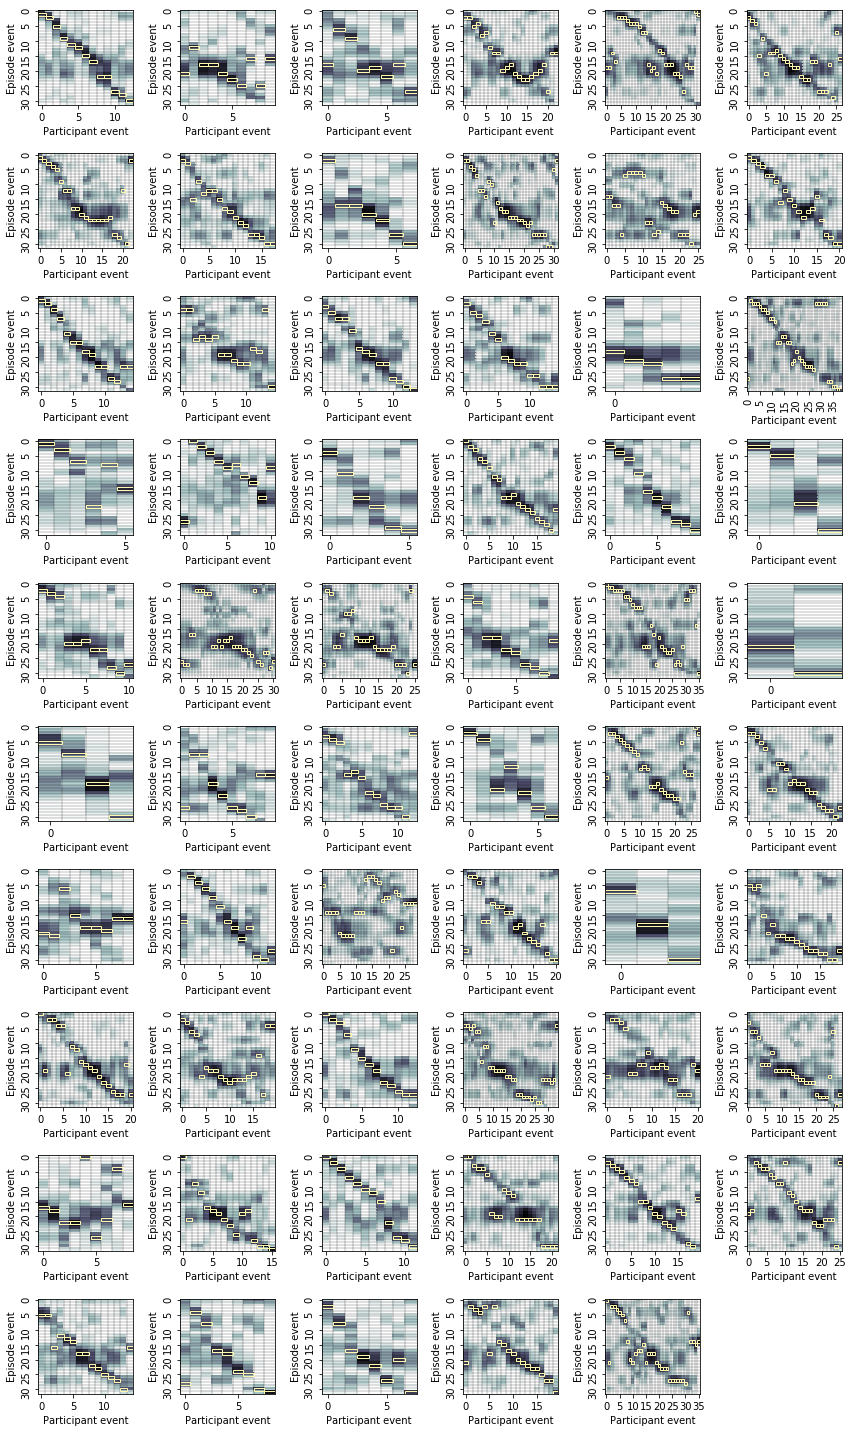

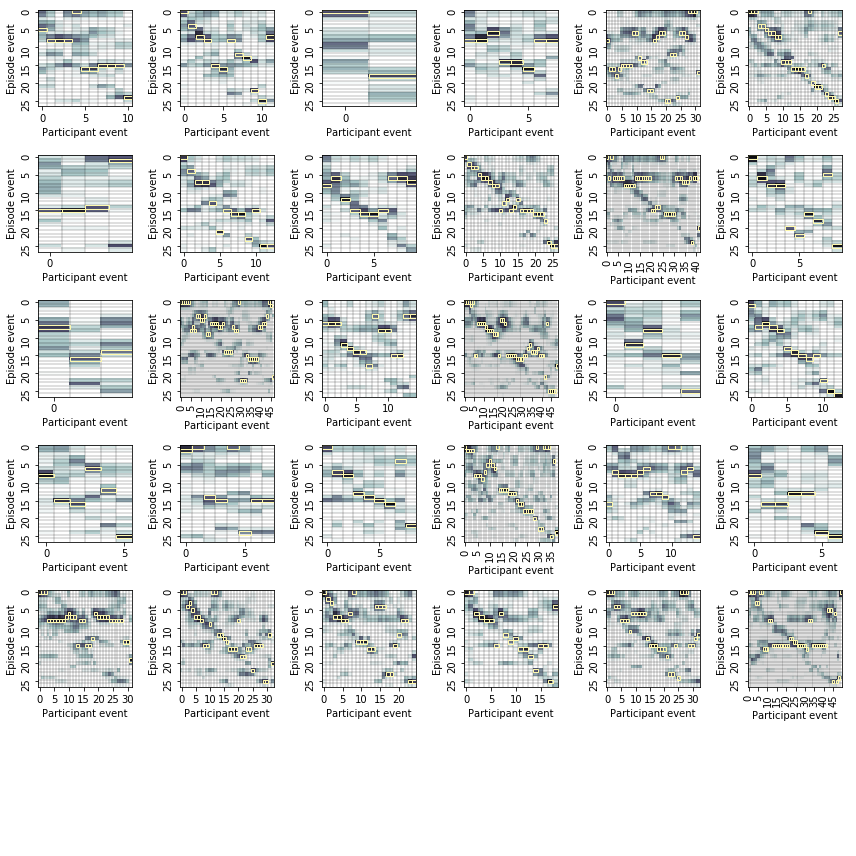

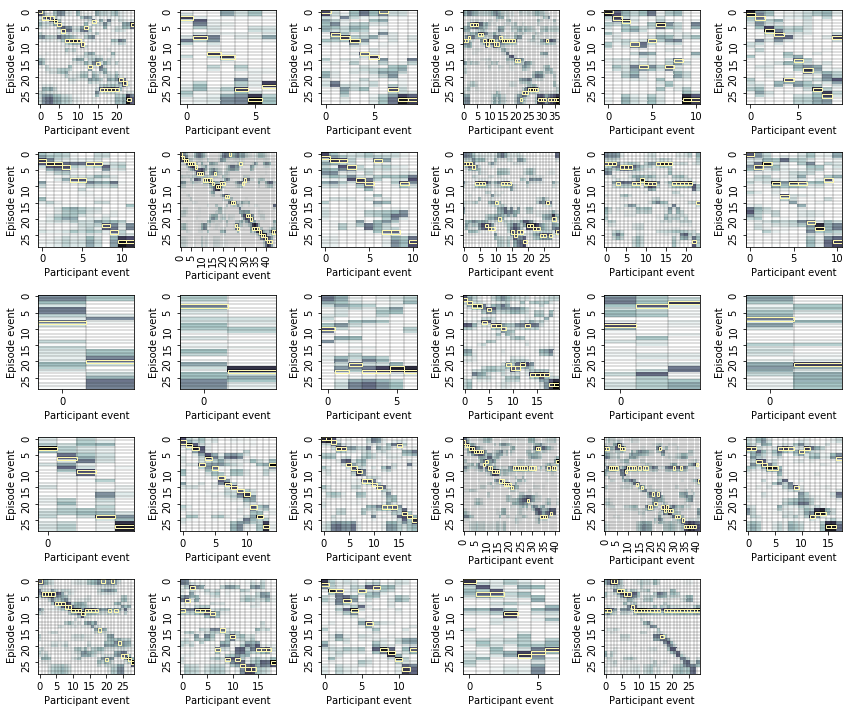

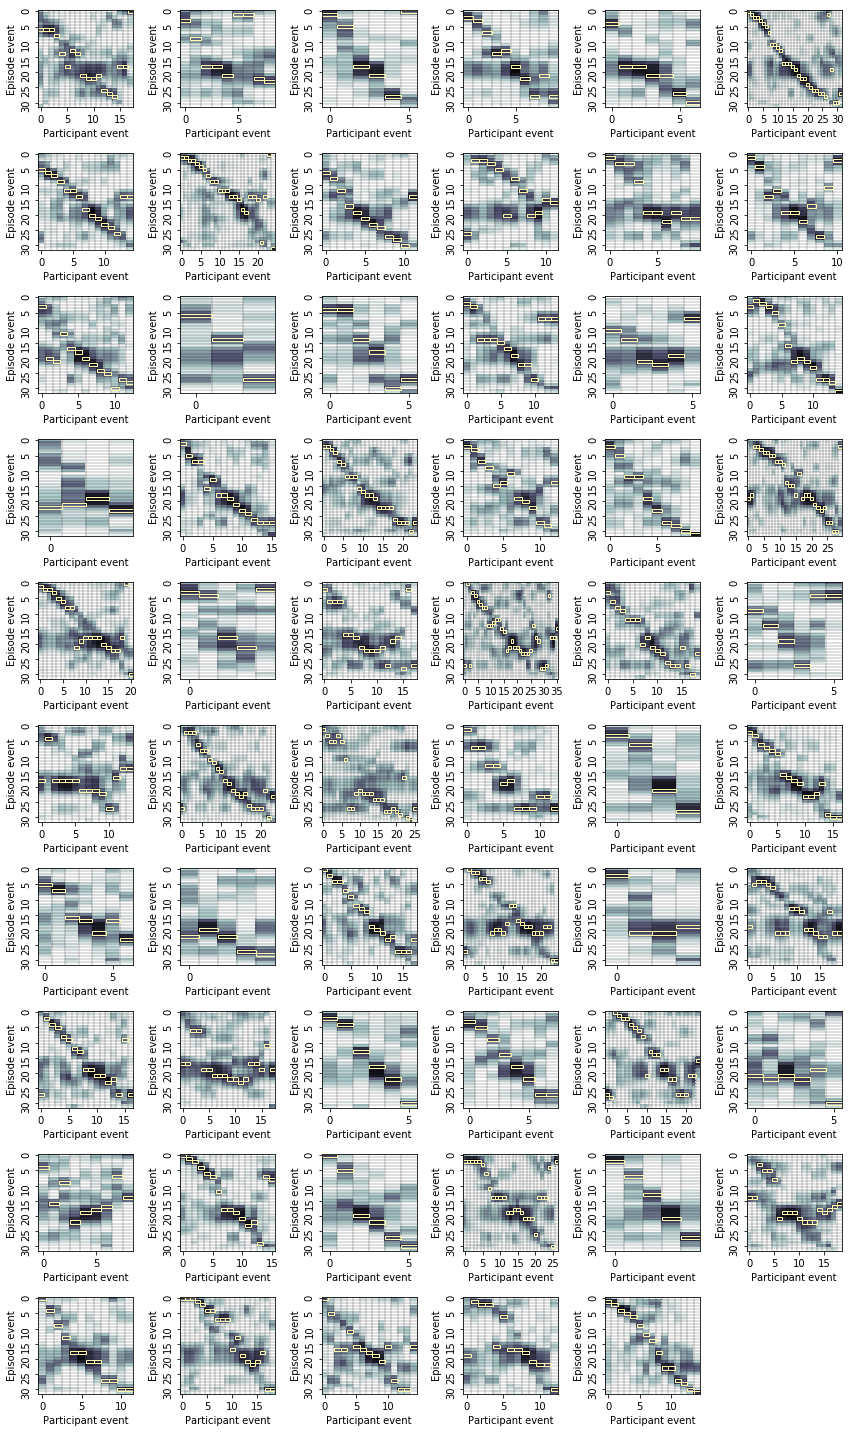

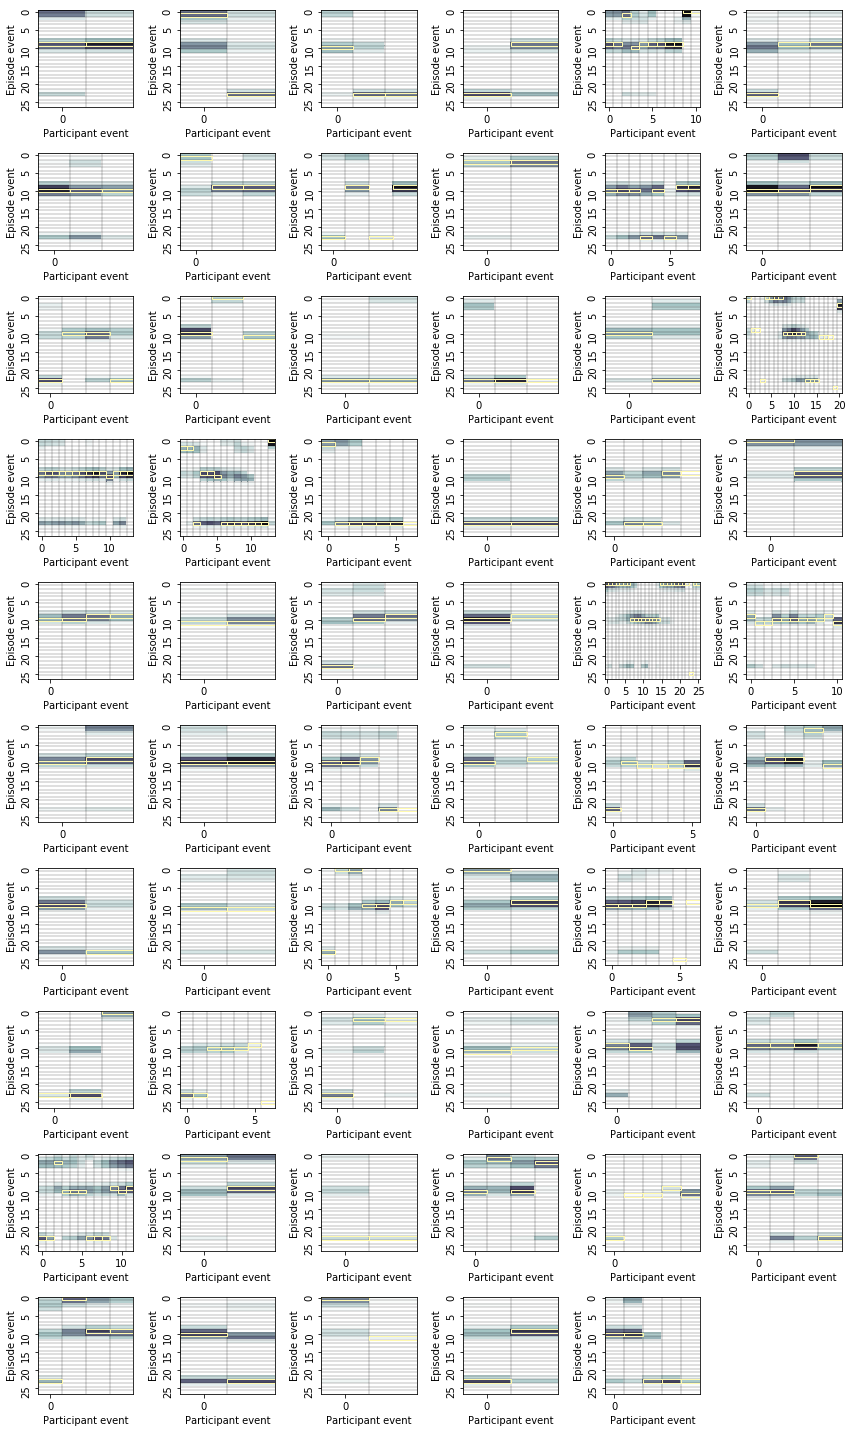

In [7]:
for rectype, mr_corrmats in corrmats.items():
    fig, axarr = plt.subplots(len(mr_corrmats)//6 + 1, 6)
    fig.set_size_inches(len(axarr[0])*2,len(axarr)*2)
    axarr = axarr.flatten()
    
    for (turkid, c), ax in zip_longest(mr_corrmats, axarr, fillvalue=(None, None)):
        
        if turkid is None:
            ax.axis('off')
            continue
            
        data = pd.DataFrame(c)
        a = sns.heatmap(data, cmap=cmap, xticklabels=5, yticklabels=5, vmin=0, vmax=1, ax=ax, cbar=False)
        a.set_xlabel('Participant event')
        a.set_ylabel('Episode event')
        
        for _, spine in a.spines.items():
            spine.set_visible(True)
        
        a.hlines(list(range(c.shape[0])), *a.get_xlim(), linewidth=.25)
        a.vlines(list(range(c.shape[1])), *a.get_ylim(), linewidth=.25)
        
        bounds = np.argmax(c, axis=0)
        for i in range(len(bounds)):
            rect = patches.Rectangle((i,bounds[i]), 1, 1, linewidth=1, edgecolor='#FFF9AE',facecolor='none', zorder=2)
            a.add_patch(rect)
            
        plt.tight_layout()
#     plt.savefig('../../figures/{0}-matchats-k:1000.pdf'.format(rectype))
    plt.show()

## does weight of off-diagonal topics influence memory 

In [ ]:
# for each participant and their recall trajectory
for 


    # get temporal correlation matrix
    
    
    # for each timepoint of TCM
    
    
        # compute mean off diagonal value
        
        
        # get distance to corresponding (or nearest) episode timepoint
        
        
    # correlate off-diag values with distances
    
    
# average correlation values across participants

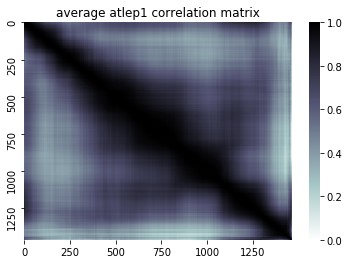

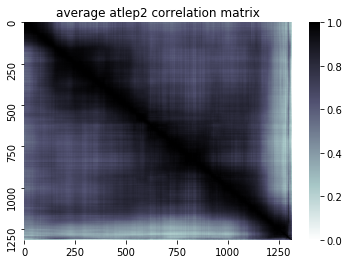

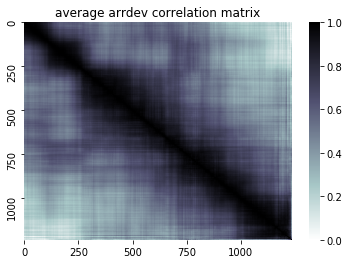

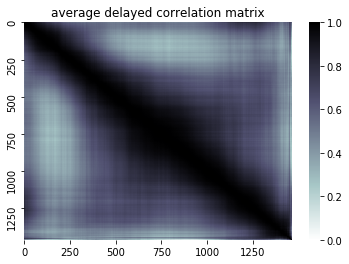

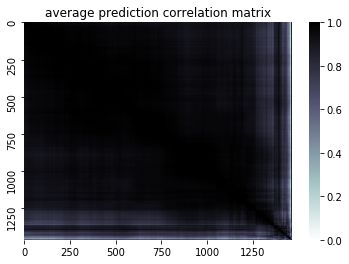

In [7]:
for rectype, traj in avg_participant_trajectories.items():
    if rectype == 'delayed':
        episode = episode_trajectories['atlep1']
    elif rectype == 'prediction':
        episode = episode_trajectories['atlep2']
    else:
        episode = 
    data = pd.DataFrame(traj).T.corr()
    a = sns.heatmap(data, cmap=cmap, xticklabels=250, yticklabels=250, vmin=0, vmax=1)
    a.set_title('average ' + rectype + ' correlation matrix')
    a.collections[0].remove()
    a.imshow(data, aspect='auto', cmap=cmap)
    plt.show()

In [28]:
[len(j) for i,j in event_mappings['atlep1'] if len(j)> 32]

[34, 36, 39, 36]

In [29]:
[len(j) for i,j in event_mappings['delayed'] if len(j)> 32]

[36]

In [30]:
[len(j) for i,j in event_mappings['arrdev'] if len(j)> 29]

[30, 42, 42, 37, 45]